<a href="https://colab.research.google.com/github/labeduc/ciencia-de-dados/blob/main/03_visualizacao/encontro-01/index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encontro 1 - Revisão e Prática: Fundamentos, Pandas e Primeiros Gráficos

Olá Cientista de Dados!

Seja muito bem-vindo ao nosso primeiro encontro ao vivo! Nosso curso segue o modelo de **sala de aula invertida**: você estudou as Aulas 01 a 07 no site antes de chegar aqui, e agora o nosso tempo juntos será dedicado ao que realmente consolida o aprendizado — tirar dúvidas, resolver exercícios em conjunto e praticar com o apoio do instrutor.

Este notebook é o nosso roteiro de hoje. Ele está organizado em três partes: uma **revisão express** do conteúdo estudado, uma sequência de **exercícios que resolveremos juntos** (com explicações adicionais em cada solução) e, ao final, a indicação das **práticas que você deverá entregar** para correção e pontuação.

Como será o nosso encontro de 1h30:

| Momento | Duração | Atividade |
|---|---|---|
| Abertura | 5 min | Dúvidas sobre o conteúdo pré-aula (Aulas 01–07) |
| Bloco 1 | 30 min | Pandas na prática: carga, inspeção, filtros e agregação (Exercícios 1 a 3) |
| Prática autônoma | 15 min | `pratica-aula-05` — Exercícios 1 a 3 |
| Bloco 2 | 20 min | Primeiros gráficos: barras, linhas e áreas (Exercícios 4 e 5) |
| Prática autônoma | 15 min | `pratica-aula-06` — exercícios selecionados |
| Encerramento | 5 min | Correção comentada e orientações de entrega |

## Antes de Começar — Checklist da Preparação

Para aproveitar esta aula, você deve ter estudado no site do curso:

| # | Aula | Conteúdo |
|---|---|---|
| 1 | Aula 01 | O que é Ciência de Dados e Visualização |
| 2 | Aula 02 | Google Colab: células, execução, atalhos |
| 3 | Aula 03 | Formatos de dados: tabular, Wide e Long |
| 4 | Aula 04 | Prática: carregando dados e `melt()` |
| 5 | Aula 05 | Pandas: inspeção, filtros e agregação |
| 6 | Aula 06 | Gráficos de barras com Seaborn |
| 7 | Aula 07 | Gráficos de linha e área |

> ⚠️ **Atenção:** se você não conseguiu estudar alguma dessas aulas, avise o instrutor no início da sessão. O tempo em sala é dedicado à prática — a exposição teórica completa está no site.

## Revisão Express (5 min)

Antes de colocar a mão na massa, vamos relembrar o mapa dos conceitos que usaremos hoje. Aproveite este momento para levantar as suas dúvidas!

| Conceito | Ferramenta / Função | Aula |
|---|---|---|
| Formato Wide vs. Long | `melt()` | 03 e 04 |
| Carregar dados | `pd.read_csv()` | 04 e 05 |
| Inspecionar um DataFrame | `head()`, `info()`, `describe()`, `shape` | 05 |
| Filtrar linhas | expressão booleana, `query()`, `loc` | 05 |
| Agregar dados | `groupby()` + `count()`, `mean()`, `max()` | 05 |
| Contagens em barras | `sns.countplot()` | 06 |
| Métricas em barras | `sns.barplot()` (com `hue` para agrupar) | 06 |
| Linhas e áreas | `sns.lineplot()`, `plt.stackplot()` | 07 |

> 💡 **Dica:** mantenha o diagrama *Visualização × Objetivo* (Aula 01) por perto — ele é o seu guia para escolher o gráfico certo em cada situação.

## Preparando o Ambiente

Vamos carregar as bibliotecas e o nosso já conhecido conjunto de dados de pokemons. Para agilizar, hoje leremos o arquivo direto da internet — sem precisar fazer upload no Colab.

In [11]:
# carregando as bibliotecas que usaremos hoje
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# lendo o dataset direto do repositório do curso
pokemons = pd.read_csv('https://github.com/labeduc/datasets/blob/main/pokemons/pokemons.csv?raw=true')

# conferindo que os dados chegaram
pokemons.head(10)

,Number,Name,Type 1,Type 2,Abilities,HP,Att,Def,Spa,Spd,...,Against Bug,Against Rock,Against Ghost,Against Dragon,Against Dark,Against Steel,Against Fairy,Height,Weight,BMI
0,1,Bulbasaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",45,49,49,65,65,...,1.00,1.0,1.0,1.0,1.0,1.0,0.5,0.7,6.9,14.1
1,2,Ivysaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",60,62,63,80,80,...,1.00,1.0,1.0,1.0,1.0,1.0,0.5,1.0,13.0,13.0
2,3,Venusaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",80,82,83,100,100,...,1.00,1.0,1.0,1.0,1.0,1.0,0.5,2.0,100.0,25.0
3,3,Mega Venusaur,Grass,Poison,['Thick Fat'],80,100,123,122,120,...,1.00,1.0,1.0,1.0,1.0,1.0,0.5,2.4,155.5,27.0
4,4,Charmander,Fire,NaN,"['Blaze', 'Solar Power']",39,52,43,60,50,...,0.50,2.0,1.0,1.0,1.0,0.5,0.5,0.6,8.5,23.6
5,5,Charmeleon,Fire,NaN,"['Blaze', 'Solar Power']",58,64,58,80,65,...,0.50,2.0,1.0,1.0,1.0,0.5,0.5,1.1,19.0,15.7
6,6,Charizard,Fire,Flying,"['Blaze', 'Solar Power']",78,84,78,109,85,...,0.25,4.0,1.0,1.0,1.0,0.5,0.5,1.7,90.5,31.3
7,6,Mega Charizard Y,Fire,Flying,['Drought'],78,104,78,159,115,...,0.25,4.0,1.0,1.0,1.0,0.5,0.5,1.7,100.5,34.8
8,6,Mega Charizard X,Fire,Dragon,['Tough Claws'],78,130,111,130,85,...,0.50,2.0,1.0,2.0,1.0,0.5,1.0,1.7,110.5,38.2
9,7,Squirtle,Water,NaN,"['Rain Dish', 'Torrent']",44,48,65,50,64,...,1.00,1.0,1.0,1.0,1.0,0.5,1.0,0.5,9.0,36.0


> 📝 **Nota:** na Aula 04 aprendemos a subir o arquivo manualmente para o Colab (upload ou Google Drive). Ler direto da URL é uma terceira forma, muito prática para aulas ao vivo — mas lembre-se de que ela depende de conexão com a internet.

## Bloco 1 — Pandas na Prática

Os três primeiros exercícios revisam o coração da Aula 05: inspecionar, filtrar e agregar dados. Dominar esses três movimentos é o que permite preparar os dados para **qualquer** gráfico.

### Exercício 1 - Conhecendo o Dataset

Todo trabalho com dados começa com um diagnóstico. Responda, com código:

1. Quantas linhas e colunas tem o dataset?
2. Quais colunas existem e qual o tipo de cada uma?
3. Existe alguma coluna com valores ausentes? Qual?

**Funções úteis:** `shape`, `info()`

> 💡 **Dica:** o `shape` é um atributo (sem parênteses!) que retorna a tupla `(linhas, colunas)`. Já o `info()` mostra, para cada coluna, o campo `Non-Null Count` — compare esse número com o total de linhas para descobrir onde há valores ausentes.

#### Solução comentada

In [3]:
# dimensões do DataFrame: (linhas, colunas)
print(pokemons.shape)


(1032, 44)


In [4]:
# estrutura: nome das colunas, contagem de não-nulos e tipo de cada uma
pokemons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number                   1032 non-null   int64  
 1   Name                     1032 non-null   object 
 2   Type 1                   1032 non-null   object 
 3   Type 2                   548 non-null    object 
 4   Abilities                1032 non-null   object 
 5   HP                       1032 non-null   int64  
 6   Att                      1032 non-null   int64  
 7   Def                      1032 non-null   int64  
 8   Spa                      1032 non-null   int64  
 9   Spd                      1032 non-null   int64  
 10  Spe                      1032 non-null   int64  
 11  BST                      1032 non-null   int64  
 12  Mean                     1032 non-null   float64
 13  Standard Deviation       1032 non-null   float64
 14  Generation              

**Explicações adicionais:**

- O dataset tem **1.032 linhas × 44 colunas** — cada linha é um pokemon, cada coluna uma característica.
- No output do `info()`, a coluna `Type 2` mostra `548 non-null`, enquanto as demais mostram `1032 non-null`. Isso significa que **484 pokemons não têm tipo secundário** — é a única coluna com valores ausentes. Guarde essa informação: ela será importante quando formos agrupar ou construir gráficos usando `Type 2`.
- Repare também nos tipos (`Dtype`): colunas numéricas aparecem como `float64`/`int64` e textuais como `object`. É por isso que `Generation` aparece como `1.0`, `2.0`... — ela é numérica, mesmo representando uma categoria.

### Exercício 2 - Filtrando os Dados

Filtrar é selecionar apenas as linhas que interessam para a análise. Faça três filtros diferentes:

1. Usando **expressão booleana**: todos os pokemons do tipo primário `Water`. Quantos são?
2. Usando **`query()`**: os pokemons **lendários** da **primeira geração**, exibindo apenas `Name`, `Type 1` e `Att`.
3. Usando **`query()`** com duas condições numéricas: pokemons com ataque (`Att`) acima de 150 **e** defesa (`Def`) acima de 100.

**Funções úteis:** `query()`, `len()`, seleção de colunas com lista

> 💡 **Dica:** dentro do `query()`, colunas com espaço no nome (como `Type 1`) precisam estar entre crases: ``query('`Type 1` == "Water"')``. E lembre-se: no dataset, a coluna `Legendary` usa `1.0` para lendário e `0.0` para não lendário.

#### Solução comentada

In [5]:
# 1. expressão booleana: o filtro vai dentro dos colchetes
agua = pokemons[pokemons['Type 1'] == 'Water']
print(len(agua), 'pokemons do tipo Water')

131 pokemons do tipo Water


In [9]:
lendarios = pokemons[pokemons['Legendary'] == True]
print(len(lendarios), 'pokemons lendários')
lendarios[["Name", "Legendary"]].head(10)

125 pokemons lendários


,Name,Legendary
182,Articuno,1.0
183,Galarian Articuno,1.0
184,Zapdos,1.0
185,Galarian Zapdos,1.0
186,Moltres,1.0
187,Galarian Moltres,1.0
191,Mewtwo,1.0
192,Mega Mewtwo Y,1.0
193,Mega Mewtwo X,1.0
194,Mew,1.0


In [15]:
# 2. query(): lendários da primeira geração
# colunas com espaço no nome usam crase dentro do query
lendarios_g1 = pokemons.query('Legendary == 1.0 and Generation == 1')
print(lendarios_g1[['Name', 'Type 1', 'Att']])

         Name    Type 1  Att
182  Articuno       Ice   85
184    Zapdos  Electric   90
186   Moltres      Fire  100
191    Mewtwo   Psychic  110
194       Mew   Psychic  100


In [10]:
# 3. query() com duas condições numéricas
fortes = pokemons.query('Att > 150 and Def > 100')
fortes[['Name', 'Type 1', 'Att', 'Def']]

,Name,Type 1,Att,Def
163,Mega Pinsir,Bug,155,120
167,Mega Gyarados,Water,155,109
262,Mega Heracross,Bug,185,115
299,Mega Tyranitar,Rock,164,150
457,Primal Groudon,Ground,180,160
527,Mega Garchomp,Dragon,170,115
576,Regigigas,Normal,160,110
834,Mega Diancie,Rock,160,110
922,Kartana,Grass,181,131
925,Dusk Mane Necrozma,Psychic,157,127


**Explicações adicionais:**

- A expressão booleana `pokemons['Type 1'] == 'Water'` gera uma série de `True`/`False` que, colocada dentro dos colchetes, seleciona apenas as linhas `True`.
- O `query()` faz a mesma coisa com uma sintaxe mais legível — repare que dentro dele usamos `and` (como no Python comum), enquanto na expressão booleana precisaríamos de `&` com parênteses em cada condição.
- Todos os filtros retornam um **novo DataFrame** — o `pokemons` original permanece intacto. Por isso salvamos os resultados em variáveis (`agua`, `lendarios_g1`, `fortes`).

### Exercício 3 - Agregando os Dados

Agregar é resumir os dados por grupo — o passo que antecede a maioria dos gráficos. Responda:

1. Qual é a **média de ataque** (`Att`) por geração, da maior para a menor?
2. Quais são os **5 tipos primários** (`Type 1`) com mais pokemons?

**Funções úteis:** `groupby()`, `mean()`, `count()`, `sort_values()`, `head()`

In [6]:
# Escreva seu código aqui — vamos resolver juntos!

> 💡 **Dica:** encadeie as funções: agrupe, calcule a métrica e depois ordene com `sort_values(ascending=False)`. Para pegar apenas os 5 primeiros, encerre com `head(5)`.

#### Solução comentada

In [17]:
# 1. média de ataque por geração, da maior para a menor
media_att = pokemons.groupby('Generation')['Att'].mean().sort_values(ascending=False)
print(media_att)


Generation
6.0    95.879699
7.0    86.112069
8.0    83.417391
5.0    82.447853
4.0    79.991379
3.0    74.021739
1.0    72.913907
2.0    68.260000
Name: Att, dtype: float64


In [18]:
# 2. os 5 tipos primários com mais pokemons
top_tipos = pokemons.groupby('Type 1')['Number'].count().sort_values(ascending=False).head(5)
top_tipos

Type 1
Water      131
Normal     114
Grass       91
Bug         81
Psychic     77
Name: Number, dtype: int64

**Explicações adicionais:**

- Leia o encadeamento da esquerda para a direita, como uma receita: *agrupe por geração → pegue a coluna `Att` → calcule a média → ordene do maior para o menor*.
- No item 2, usamos `count()` na coluna `Number` só para contar as linhas de cada grupo — qualquer coluna sem valores ausentes serviria. Cuidado ao contar por colunas com nulos (como `Type 2`): o `count()` ignora os ausentes!
- Este padrão `groupby → métrica → sort_values` será o motor de quase todos os gráficos que faremos daqui em diante.

## Agora é com você! — Prática Autônoma (15 min)

Abra o notebook **`pratica-aula-05`** e resolva os **Exercícios 1 a 3**. O instrutor estará disponível para apoiar. O que não der tempo de terminar em sala fará parte da sua entrega pontuada (veja a seção final deste notebook).

## Bloco 2 — Primeiros Gráficos

Agora que sabemos preparar os dados, vamos ao que interessa: transformá-los em gráficos. Os dois exercícios a seguir revisam as Aulas 06 e 07.

### Exercício 4 - Do Wide ao Long: Comparando Atributos em Barras

Crie um **gráfico de colunas agrupadas** comparando a **média de ataque** (`Att`) e a **média de defesa** (`Def`) por geração — uma cor para cada atributo.

O gráfico deve ter:
- Título: `Média de Ataque e Defesa por Geração`
- Rótulo do eixo X: `Geração`
- Rótulo do eixo Y: `Média dos pontos`
- Sem barras de margem de erro

**Funções úteis:** `melt()`, `barplot()` com `hue=`, `err_kws={"linewidth": 0}`

> 💡 **Dica:** o Seaborn espera os dados no formato **longo** para usar o `hue`. Selecione primeiro as colunas (`pokemons[['Generation', 'Att', 'Def']]`), aplique o `melt(id_vars='Generation')` e só então plote.

#### Solução comentada

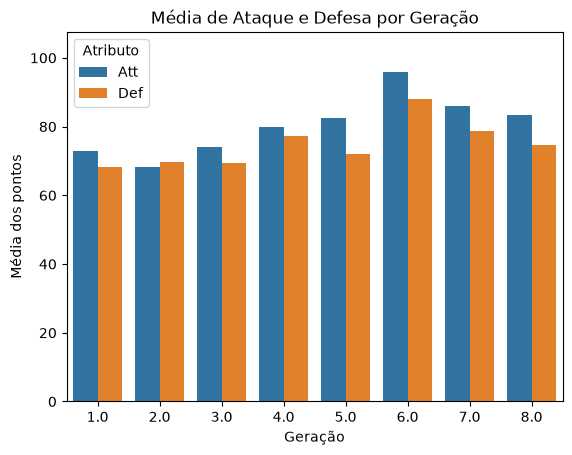

In [19]:
# selecionamos apenas as colunas envolvidas e transformamos para o formato longo
base = pokemons[['Generation', 'Att', 'Def']]
# print(base.head())

tidy = base.melt(id_vars='Generation', var_name='Atributo', value_name='Pontos')
#tidy.head(9)

# gráfico de colunas agrupadas: uma cor por atributo
sns.barplot(tidy, x='Generation', y='Pontos', hue='Atributo', err_kws={"linewidth": 0})

# títulos e rótulos dos eixos
plt.title('Média de Ataque e Defesa por Geração')
plt.xlabel('Geração')
plt.ylabel('Média dos pontos')

# exibe o gráfico
plt.show()

**Explicações adicionais:**

- O `melt()` "derreteu" as colunas `Att` e `Def` em duas novas colunas: `Atributo` (qual era a coluna) e `Pontos` (o valor). É essa estrutura que permite ao `hue` pintar uma cor por atributo.
- O `barplot()` calcula a **média** por padrão (esse é o seu `estimator`) — por isso não precisamos agrupar antes.
- O `err_kws={"linewidth": 0}` esconde as barras de erro. Essa é a sintaxe atual do Seaborn (o antigo `errwidth=0` está depreciado).

### Exercício 5 - Linhas e Áreas

Vamos analisar como os **atributos especiais** evoluem ao longo das gerações:

1. Agrupe os dados calculando a **média** de `Spa` (ataque especial) e `Spd` (defesa especial) por geração.
2. Plote um **gráfico de linhas** com as duas séries.
3. Plote a versão em **gráfico de área empilhada** — com legenda visível!

**Funções úteis:** `groupby()`, `reset_index()`, `lineplot()` com `hue=`, `plt.stackplot()`, `plt.legend()`

> 💡 **Dica:** para o `lineplot()` com duas séries, use o mesmo truque do `melt()` do exercício anterior. Já o `stackplot()` é do Matplotlib puro e recebe as colunas separadamente: `plt.stackplot(x, serie1, serie2, labels=[...])` — e não se esqueça do `plt.legend()`, senão as áreas ficam sem identificação.

#### Solução comentada

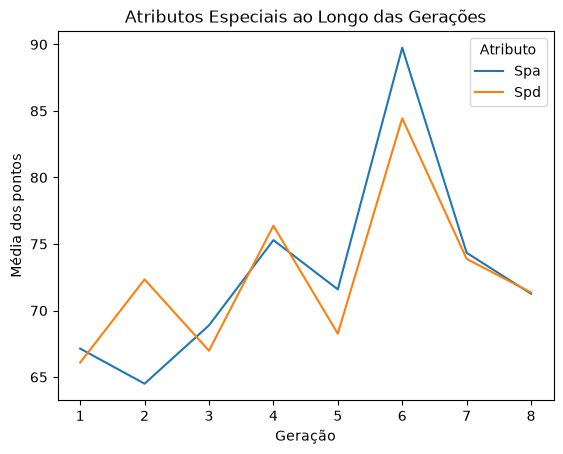

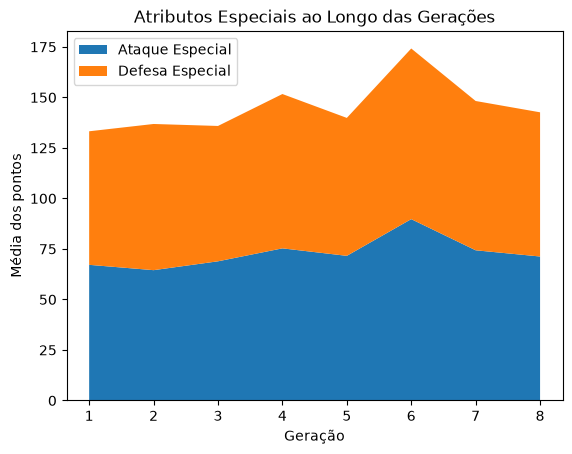

In [11]:
# média dos atributos especiais por geração
pokemons_gb = pokemons.groupby('Generation')[['Spa', 'Spd']].mean().reset_index()

# 1. gráfico de linhas com duas séries (formato longo + hue)
tidy = pokemons_gb.melt(id_vars='Generation', var_name='Atributo', value_name='Pontos')
sns.lineplot(tidy, x='Generation', y='Pontos', hue='Atributo', errorbar=None)
plt.title('Atributos Especiais ao Longo das Gerações')
plt.xlabel('Geração')
plt.ylabel('Média dos pontos')
plt.show()

# 2. gráfico de área empilhada com o Matplotlib puro
plt.stackplot(pokemons_gb['Generation'], pokemons_gb['Spa'], pokemons_gb['Spd'],
              labels=['Ataque Especial', 'Defesa Especial'])
plt.title('Atributos Especiais ao Longo das Gerações')
plt.xlabel('Geração')
plt.ylabel('Média dos pontos')

# adiciona a legenda para identificarmos cada área
plt.legend(loc='upper left')
plt.show()

**Explicações adicionais:**

- Repare na diferença entre as duas APIs: o `lineplot()` (Seaborn) trabalha com o DataFrame no formato longo e resolve as cores sozinho via `hue`; o `stackplot()` (Matplotlib) recebe cada série separadamente e exige a chamada explícita de `plt.legend()`.
- No gráfico de **área empilhada**, as séries são somadas: a linha de cima representa `Spa + Spd`. Use esse tipo de gráfico quando o **total** também for uma informação relevante.
- Aqui agrupamos com `groupby().mean()` antes de plotar porque o `stackplot()` não calcula médias — ele plota exatamente os valores que recebe.

## Agora é com você! — Prática Autônoma (15 min)

Abra o notebook **`pratica-aula-06`** e resolva os exercícios indicados pelo instrutor (sugestão: Exercícios 1, 3 e 4). Os demais fazem parte da entrega pontuada.

## Práticas para Entrega 🎯

Para consolidar (e pontuar!) o conteúdo deste encontro, você deve completar e entregar **duas práticas**:

| Prática | Exercícios | Conteúdo avaliado |
|---|---|---|
| `pratica-aula-05` | 1 a 5 | Inspeção, estatísticas, filtros e agregação com Pandas |
| `pratica-aula-06` | 1 a 5 | Gráficos de colunas, barras, `hue`/`melt()` e barras empilhadas |

**Como entregar:**
1. Resolva os exercícios nos próprios notebooks das práticas, no Google Colab.
2. Execute o notebook do início ao fim (`Ambiente de execução → Reiniciar e executar tudo`) para garantir que não há erros.
3. Salve no seu Google Drive e compartilhe o link com o instrutor, conforme a orientação da turma.

**Prazo:** antes do Encontro 2.

**Critérios de pontuação:**
- ✅ O notebook executa do início ao fim sem erros
- ✅ Todos os gráficos têm título e rótulos nos eixos
- ✅ As perguntas interpretativas foram respondidas em texto
- ✅ O código está organizado e comentado

> 💡 **Dica:** não deixe para a véspera! As dúvidas que surgirem durante as práticas podem ser trazidas para o início do Encontro 2.

## Finalizando

Hoje revisamos, na prática, todo o caminho que vai do dado bruto ao primeiro gráfico: carregar, inspecionar, filtrar, agregar, transformar para o formato longo e plotar barras, linhas e áreas. Esse é o alicerce de tudo o que vem no próximo encontro, quando avançaremos para dispersão, quadrantes, gráficos avançados e visualizações interativas com Plotly.

Links para consulta:
- [Documentação do Pandas](https://pandas.pydata.org/docs/)
- [Documentação do Seaborn](https://seaborn.pydata.org/)
- [Documentação do Matplotlib](https://matplotlib.org/stable/index.html)

Um abraço e até a próxima,

Walter.